# 01. LangGraph 개념 이해

---

## LangGraph란?

**LangGraph**는 AI 워크플로우를 그래프로 구성하는 **상태 기반 오케스트레이션 프레임워크**이다.

> LangChain v1의 Agent(`create_agent`)는 LangGraph 런타임을 기반으로 동작합니다.
> 과거에는 `langgraph.prebuilt.create_react_agent`가 자주 사용되었으나,
> LangGraph v1 이후에는 deprecated 되었고 `langchain.agents.create_agent` 사용이 권장됩니다.

### LangChain(LCEL)만으로는 부족한 이유
LangChain LCEL은 주로 입력 → 처리 → 출력 형태의 체인 구성에 적합하다.
단순 분기나 병렬 처리는 가능하지만, 상태를 유지하면서 반복·조건 분기·멀티 에이전트 흐름을 명확하게 관리하려면 LangGraph가 더 적합하다.

```text
LangChain LCEL
  입력 → 프롬프트 → 모델 → 출력
  단순 체인 구성에 적합

LangGraph          가능
  A → B → C
      ↓
      D → (조건 판단) → E
              ↓
             다시 B로 (루프)

  상태 기반 분기.반복.멀티 에이전트 구성에 적합하다
```

### LangGraph가 필요한 상황

| 상황 | 설명 |
|---|---|
| **분기(Branch)** | 조건에 따라 다른 경로 실행 |
| **반복(Loop)** | 결과가 만족스러울 때까지 재시도 |
| **멀티 에이전트** | 여러 에이전트가 협력 |
| **상태 관리** | 대화 히스토리·중간 결과 유지 |

---

## LangGraph 3대 구성 요소

```text
┌──────────────────────────────────────────┐
│                LangGraph                 │
│                                          │
│  ┌─────────┐    ┌─────────┐              │
│  │  State  │    │  Node   │              │
│  │ (상태)  │←──→│ (작업)  │              │
│  └─────────┘    └─────────┘              │
│        ↑              ↑                  │
│        └──── Edge ────┘                  │
│             (연결)                       │
└──────────────────────────────────────────┘

State : 그래프 전체에서 공유하는 데이터 저장소
Node  : State를 받아 처리하고 업데이트를 반환하는 함수
        (안에서 ChatModel, Tool 등 LangChain 컴포넌트 사용)
Edge  : Node 간 실행 순서를 정의하는 연결선
```

In [2]:
from dotenv import load_dotenv
load_dotenv(override=True, dotenv_path="../.env")

True

---

## 첫 번째 LangGraph: 숫자 계산기

가장 단순한 그래프로 핵심 구조를 이해한다.

```
START → [더하기] → [곱하기] → [결과출력] → END
```

### Step 1. State 정의

`State`는 그래프 전체에서 공유하는 **데이터 저장소**이다.  
`TypedDict`로 타입을 명시하면 자동 완성과 오류 체크에 유용하다.

In [1]:
from typing import TypedDict

# State 정의: 그래프 전체에서 공유되는 데이터 구조
class CalcState(TypedDict):
    num1: int      # 첫 번째 숫자
    num2: int      # 두 번째 숫자
    result: int    # 계산 결과

# State는 단순히 TypedDict 클래스입니다
print("State 정의 완료:", CalcState.__annotations__)

State 정의 완료: {'num1': <class 'int'>, 'num2': <class 'int'>, 'result': <class 'int'>}


### Step 2. Node 정의

Node는 `State`를 입력받고, **변경된 부분만 딕셔너리로 반환**하는 함수이다.

In [2]:
# Node: State를 입력으로 받아 처리 후 업데이트된 딕셔너리 반환
def add_node(state: CalcState) -> dict:
    """두 숫자를 더하는 노드"""
    result = state["num1"] + state["num2"]
    return {"result": result}

def multiply_node(state: CalcState) -> dict:
    """두 숫자를 곱하는 노드"""
    result = state["num1"] * state["num2"]
    return {"result": result}


def print_result(state: CalcState) -> dict[str, int]:
    """Node 3: 결과를 저장한다"""
    print(f"  [결과 노드] 최종 결과 = {state['result']}")
    return {"result": state["result"]}

print("Node 정의 완료")

Node 정의 완료


### Step 3. Graph 생성 및 Edge 연결

In [3]:
from langgraph.graph import StateGraph, START, END

# ① 그래프 빌더 생성 (State 타입을 지정)
builder = StateGraph(CalcState)

# ② Node 등록(이름, 함수)
builder.add_node("add", add_node)
builder.add_node("multiply", multiply_node)
builder.add_node("print_result", print_result)

# ③ Edge 연결 (실행 순서 정의)
builder.add_edge(START,    "add")    # 시작 → 더하기
builder.add_edge("add", "multiply")    # 더하기 → 곱하기
builder.add_edge("multiply", "print_result")  # 곱하기 → 결과출력
builder.add_edge("print_result", END)        # 결과출력 → 종료

# ④ 그래프 컴파일 (실행 가능한 상태로 변환)
graph = builder.compile()

print("그래프 컴파일 완료")

그래프 컴파일 완료


### Step 4. 그래프 시각화

LangGraph는 3가지 방법으로 그래프를 시각화할 수 있다.

ASCII 그래프 시각화를 사용하려면 `grandalf` 패키지가 필요할 수 있다.
아래 명령으로 설치합니다.

```bash
uv add grandalf
```

In [4]:
# 방법 1: ASCII 텍스트 형태로 시각화
print("[방법 1: ASCII 시각화]")
print(graph.get_graph().draw_ascii())

[방법 1: ASCII 시각화]
+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
   +-----+     
   | 더하기 |     
   +-----+     
      *        
      *        
      *        
   +-----+     
   | 곱하기 |     
   +-----+     
      *        
      *        
      *        
  +------+     
  | 결과출력 |     
  +------+     
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   


In [5]:
# 방법 2: Mermaid 문법 출력
print("[방법 2: Mermaid 문법]")
print(graph.get_graph().draw_mermaid())

[방법 2: Mermaid 문법]
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	\b354\d558\ae30(더하기)
	\acf1\d558\ae30(곱하기)
	\acb0\acfc\cd9c\b825(결과출력)
	__end__([<p>__end__</p>]):::last
	__start__ --> \b354\d558\ae30;
	\acf1\d558\ae30 --> \acb0\acfc\cd9c\b825;
	\b354\d558\ae30 --> \acf1\d558\ae30;
	\acb0\acfc\cd9c\b825 --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



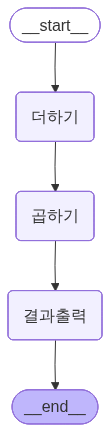

In [6]:
# 방법 3: PNG 이미지 (인터넷 필요 - Mermaid API 사용)
from IPython.display import Image, display

try:
    img = graph.get_graph().draw_mermaid_png()
    display(Image(img))
except Exception as e:
    print(f"이미지 생성 실패 (인터넷 연결 확인): {e}")
    print("→ ASCII 시각화를 사용하세요")

### Step 5. 그래프 실행

In [8]:
# invoke(): 초기 State를 입력해서 실행
print("=== 그래프 실행 (시작 숫자: 5) ===")
initial_state = {"num1": 5, "num2": 10, "result": 0}

final_state = graph.invoke(initial_state)

print(f"\n최종 State: {final_state}")
print(f"계산 결과: (5 + 10) x 2 = {final_state['result']}")

=== 그래프 실행 (시작 숫자: 5) ===
  [결과 노드] 최종 결과 = 50

최종 State: {'num1': 5, 'num2': 10, 'result': 50}
계산 결과: (5 + 10) x 2 = 50


In [9]:
# stream(): 각 노드의 실행 결과를 실시간으로 확인
print("=== 스트림 실행 (단계별 State 변화) ===")

for step in graph.stream({"num1": 3, "num2": 4, "result": 0}):
    node_name = list(step.keys())[0]
    node_output = step[node_name]
    print(f"  [{node_name}] 출력: {node_output}")

=== 스트림 실행 (단계별 State 변화) ===
  [더하기] 출력: {'result': 7}
  [곱하기] 출력: {'result': 12}
  [결과 노드] 최종 결과 = 12
  [결과출력] 출력: {'result': 12}


---

# 핵심 개념 정리

```python
# LangGraph 기본 패턴

# 1. State 정의
class MyState(TypedDict):
    key: type

# 2. Node 정의 (State → dict 반환)
def my_node(state: MyState) -> dict:
    return {"key": new_value}

# 3. Graph 구성
builder = StateGraph(MyState)
builder.add_node("노드이름", my_node)
builder.add_edge(START, "노드이름")
builder.add_edge("노드이름", END)

# 4. 컴파일 & 실행
graph = builder.compile()
result = graph.invoke({"key": initial_value})
```

| 메서드 | 설명 |
|---|---|
| `invoke()` | 동기 실행, 최종 State 반환 |
| `stream()` | 각 노드 실행 결과를 순서대로 yield |
| `get_graph().draw_ascii()` | ASCII 그래프 (오프라인) |
| `get_graph().draw_mermaid_png()` | PNG 이미지 (인터넷 필요) |
